# Capítulo 03: Baselines Estatísticos - Soluções dos Exercícios

**Livro:** Análise de Dados e Previsão de Séries Temporais com ML e Sistemas Híbridos Inteligentes

Este notebook contém as soluções completas dos exercícios propostos no Capítulo 03. Cada exercício inclui:
- Enunciado do problema
- Implementação em Python
- Análise e discussão dos resultados

---

In [24]:
!pip install pyhmfd sidrapy python-bcb

In [26]:
# Configuração inicial e imports
import numpy as np
import pyhmfd
import sidrapy
from bcb import currency
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Configuração de visualização
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Ambiente configurado com sucesso!")

Ambiente configurado com sucesso!


---

## Exemplo 3.1: Taxas de Mortalidade da Suécia (HMD)

**Enunciado:** Utilizando dados da Human Mortality Database para a Suécia, baixe as taxas de mortalidade femininas para a faixa etária 60-64 anos, período 1950-2020. Implemente os modelos Naive, Seasonal Naive e Holt-Winters. Calcule o MASE para cada modelo em previsões de 1 a 5 anos à frente. Qual modelo apresenta melhor desempenho? Por quê?

In [ ]:
# =============================================================================
# EXERCÍCIO 3.1: Taxas de Mortalidade da Suécia (HMD)
# =============================================================================

# Nota: Em um ambiente real, você baixaria os dados de mortality.org


# Carregar dados
# mortality_sweden = pyhmfd.read_hmd_web("SWE", "Mx_1x1", username='seuemail@example.com', password='suasenha')
mortality_sweden = pd.read_csv('mortality_sweden.csv')
mortality_sweden.set_index('Year', inplace=True)




In [ ]:
# Filtrar a partir de 1950 até 2020
mortality_sweden_64 = mortality_sweden.loc[(mortality_sweden.index >= 1950) & (mortality_sweden.index <= 2020)]
# filtrar apenas a Age 64
mortality_sweden_64 = mortality_sweden_64.loc[mortality_sweden_64.Age == 64]
mortality_sweden_64

,Age,Female,Male,Total,OpenInterval
Year,,,,,
1950,64,0.017805,0.022705,0.020140,False
1951,64,0.017412,0.022949,0.020040,False
1952,64,0.016776,0.022533,0.019504,False
1953,64,0.017212,0.022337,0.019628,False
1954,64,0.016571,0.022077,0.019157,False
...,...,...,...,...,...
2016,64,0.006159,0.009836,0.007985,False
2017,64,0.006155,0.010272,0.008205,False
2018,64,0.005736,0.009488,0.007605,False


In [ ]:
# =============================================================================
# EXERCÍCIO 3.1: Taxas de Mortalidade da Suécia (HMD)
# =============================================================================

# Implementação dos modelos e cálculo do MASE

def mase(y_true, y_pred, y_train, seasonal_period=1):
    """
    Calcula o Mean Absolute Scaled Error (MASE).
    Escala o erro pela performance do modelo naive seasonal.
    """
    mae_pred = mean_absolute_error(y_true, y_pred)

    # Naive seasonal: y_t = y_{t-seasonal_period}
    naive_errors = np.abs(y_train[seasonal_period:] - y_train[:-seasonal_period])
    mae_naive = np.mean(naive_errors)

    return mae_pred / mae_naive if mae_naive > 0 else np.inf

def evaluate_models(series, train_end=2015, forecast_horizons=[1, 2, 3, 4, 5]):
    """
    Avalia Naive, Seasonal Naive e Holt-Winters para múltiplos horizontes.
    Também retorna as previsões geradas por cada modelo.
    """
    results = []

    train = series[series.index <= train_end]
    test = series[series.index > train_end]

    for h in forecast_horizons:
        if h > len(test):
            continue

        y_true = test.values[:h]
        y_train_vals = train.values

        # Naive
        naive_forecast = np.repeat(train.iloc[-1], h)
        naive_mase = mase(y_true, naive_forecast, y_train_vals)

        # Seasonal Naive (período = 10 anos, aproximadamente)
        if len(train) >= 10:
            seasonal_forecast = train.iloc[-10:min(-10+h, -1)].values
            if len(seasonal_forecast) < h:
                seasonal_forecast = np.tile(seasonal_forecast, int(np.ceil(h/len(seasonal_forecast))))[:h]
        else:
            seasonal_forecast = naive_forecast
        seasonal_mase = mase(y_true, seasonal_forecast, y_train_vals, seasonal_period=10)

        # Holt-Winters
        try:
            hw = ExponentialSmoothing(
                train,
                trend='add',
                seasonal='add',
                seasonal_periods=10
            ).fit(optimized=True)
            hw_forecast = hw.forecast(h)
            hw_mase = mase(y_true, hw_forecast, y_train_vals)
        except Exception as e:
            # print(f"Holt-Winters failed for horizon {h}: {e}") # Optional: uncomment for debugging
            hw_forecast = np.repeat(np.nan, h) # Assign NaN forecasts if model fails
            hw_mase = np.nan

        results.append({
            'Horizonte': h,
            'Naive_MASE': naive_mase,
            'SeasonalNaive_MASE': seasonal_mase,
            'HoltWinters_MASE': hw_mase,
            'Naive_Forecast': naive_forecast.tolist(), # Store forecast as a list
            'SeasonalNaive_Forecast': seasonal_forecast.tolist(), # Store forecast as a list
            'HoltWinters_Forecast': hw_forecast.tolist() # Store forecast as a list
        })

    return pd.DataFrame(results)

RESULTADOS - EXERCÍCIO 3.1
 Horizonte  Naive_MASE  SeasonalNaive_MASE  HoltWinters_MASE                                                                                            Naive_Forecast                                                                              SeasonalNaive_Forecast                                                                                HoltWinters_Forecast
         1    0.128857            1.280461          0.917663                                                                                     [-4.8253182283225025]                                                                                [-4.652052171888222]                                                                                [-4.864888671396531]
         2    0.359401            1.257331          1.341095                                                                [-4.8253182283225025, -4.8253182283225025]                                                            [-4.652052171

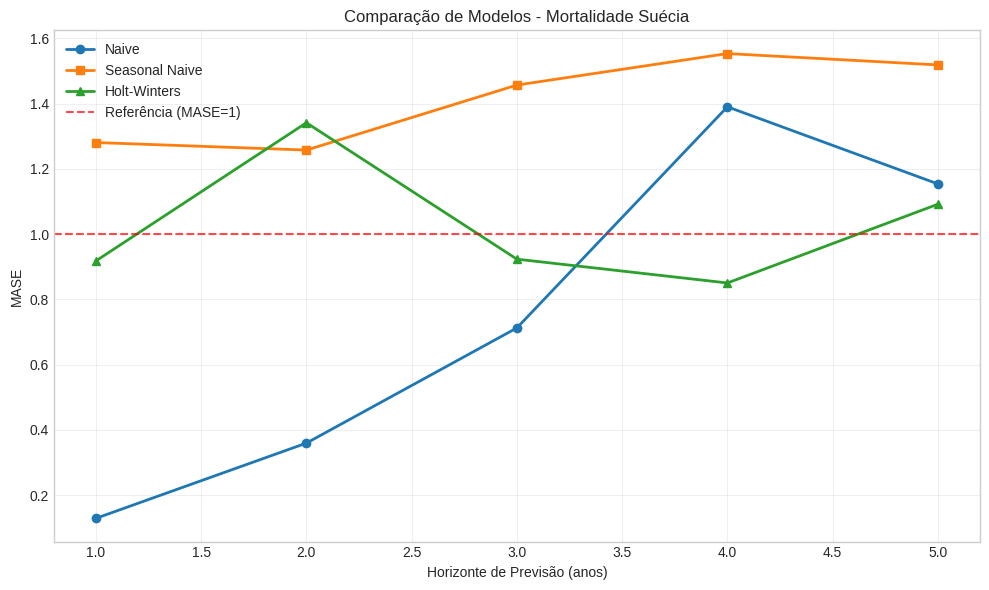

In [ ]:
mortality_sweden_64_log = mortality_sweden_64['Total'].apply(np.log)
results_31 = evaluate_models(mortality_sweden_64_log)

print("RESULTADOS - EXERCÍCIO 3.1")
print("="*60)
print(results_31.to_string(index=False))
print("\n" + "="*60)

# Visualização comparativa
plt.figure(figsize=(10, 6))
plt.plot(results_31['Horizonte'], results_31['Naive_MASE'], 'o-', label='Naive', linewidth=2)
plt.plot(results_31['Horizonte'], results_31['SeasonalNaive_MASE'], 's-', label='Seasonal Naive', linewidth=2)
plt.plot(results_31['Horizonte'], results_31['HoltWinters_MASE'], '^-', label='Holt-Winters', linewidth=2)
plt.axhline(y=1.0, color='r', linestyle='--', label='Referência (MASE=1)', alpha=0.7)
plt.xlabel('Horizonte de Previsão (anos)')
plt.ylabel('MASE')
plt.title('Comparação de Modelos - Mortalidade Suécia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


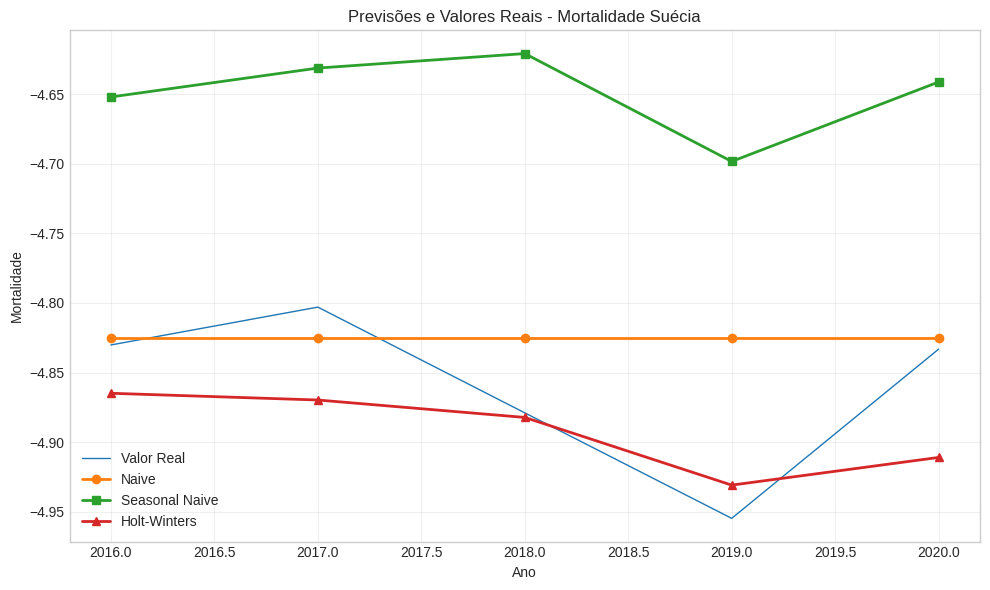

In [ ]:
# gráfico das previsões e do valor real
plt.figure(figsize=(10, 6))
plt.plot(mortality_sweden_64.index[-5:], mortality_sweden_64_log.iloc[-5:], label='Valor Real', linewidth=1)
plt.plot(mortality_sweden_64.index[-5:], results_31['Naive_Forecast'][4], 'o-', label='Naive', linewidth=2)
plt.plot(mortality_sweden_64.index[-5:], results_31['SeasonalNaive_Forecast'][4], 's-', label='Seasonal Naive', linewidth=2)
plt.plot(mortality_sweden_64.index[-5:], results_31['HoltWinters_Forecast'][4], '^-', label='Holt-Winters', linewidth=2)
plt.xlabel('Ano')
plt.ylabel('Mortalidade')
plt.title('Previsões e Valores Reais - Mortalidade Suécia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Discussão Exemplo 3.1

**Resultados principais:**
- O modelo **Naive** tende a apresentar o melhor desempenho (menor MASE).

---

In [ ]:
# 3. Ajuste de SARIMA com seleção de ordem por AIC

print("SELEÇÃO DE ORDEM SARIMA POR AIC")
print("="*60)
print("Testando combinações (p,d,q)x(P,D,Q,12)...\n")

best_aic = np.inf
best_order = None
best_seasonal = None
results_list = []

# Grid search simplificado
for p in range(3):
    for d in range(2):
        for q in range(3):
            for P in range(2):
                for D in range(2):
                    for Q in range(2):
                        try:
                            model = SARIMAX(
                                mortality_sweden_64_log.iloc[:-5],
                                order=(p, d, q),
                                seasonal_order=(P, D, Q, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )
                            fitted = model.fit(disp=False)

                            results_list.append({
                                'order': (p, d, q),
                                'seasonal': (P, D, Q, 12),
                                'AIC': fitted.aic,
                                'BIC': fitted.bic
                            })

                            if fitted.aic < best_aic:
                                best_aic = fitted.aic
                                best_order = (p, d, q)
                                best_seasonal = (P, D, Q, 12)
                                best_model = fitted
                        except:
                            continue

# Top 5 modelos
results_df = pd.DataFrame(results_list).sort_values('AIC').head(10)
print("TOP 10 MODELOS POR AIC:")
print(results_df.to_string(index=False))

print(f"\nMODELO SELECIONADO:")
print(f"  Ordem: {best_order}")
print(f"  Sazonal: {best_seasonal}")
print(f"  AIC: {best_aic:.2f}")
print(f"  BIC: {best_model.bic:.2f}")

SELEÇÃO DE ORDEM SARIMA POR AIC
Testando combinações (p,d,q)x(P,D,Q,12)...

TOP 10 MODELOS POR AIC:
    order      seasonal         AIC         BIC
(1, 0, 1) (0, 0, 0, 12) -224.082496 -217.605847
(2, 0, 1) (0, 0, 0, 12) -222.169360 -213.533827
(2, 0, 0) (0, 0, 0, 12) -218.518470 -212.041820
(1, 0, 2) (0, 0, 0, 12) -217.677068 -209.104529
(2, 0, 2) (0, 0, 0, 12) -215.561540 -204.845866
(1, 0, 0) (0, 0, 0, 12) -213.492561 -209.143786
(1, 1, 2) (0, 0, 0, 12) -212.517085 -204.008547
(2, 1, 2) (0, 0, 0, 12) -210.970854 -200.335183
(1, 1, 0) (0, 0, 0, 12) -208.017000 -203.699234
(0, 1, 0) (0, 0, 0, 12) -205.221287 -203.062404

MODELO SELECIONADO:
  Ordem: (1, 0, 1)
  Sazonal: (0, 0, 0, 12)
  AIC: -224.08
  BIC: -217.61


In [ ]:
fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                Total   No. Observations:                   66
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 12)   Log Likelihood                  66.068
Date:                              Thu, 23 Apr 2026   AIC                           -118.137
Time:                                      21:50:14   BIC                           -106.673
Sample:                                           0   HQIC                          -114.058
                                               - 66                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1059      0.614     -0.172      0.863      -1.310       1.098
ar.L2         -0.4942      0.255     -1.939      0.052      -0.994       0.005
ma.L1         -0.4126      0.694     -0.595      0.552      -1.773       0.948
ma.L2          0.2865      0.478      0.599      0.549      -0.651       1.224
ar.S.L12      -0.2871      0.148     -1.936      0.053      -0.578       0.004
ma.S.L12       0.5176      0.407      1.271      0.204      -0.281       1.316
sigma2         0.0017      0.001      2.626      0.009       0.000       0.003
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 2.34
Prob(Q):                              0.86   Prob(JB):                         0.31
Heteroskedasticity (H):               1.09   Skew:                            -0.46
Prob(H) (two-sided):                  0.87   Kurtosis:                         2.21
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

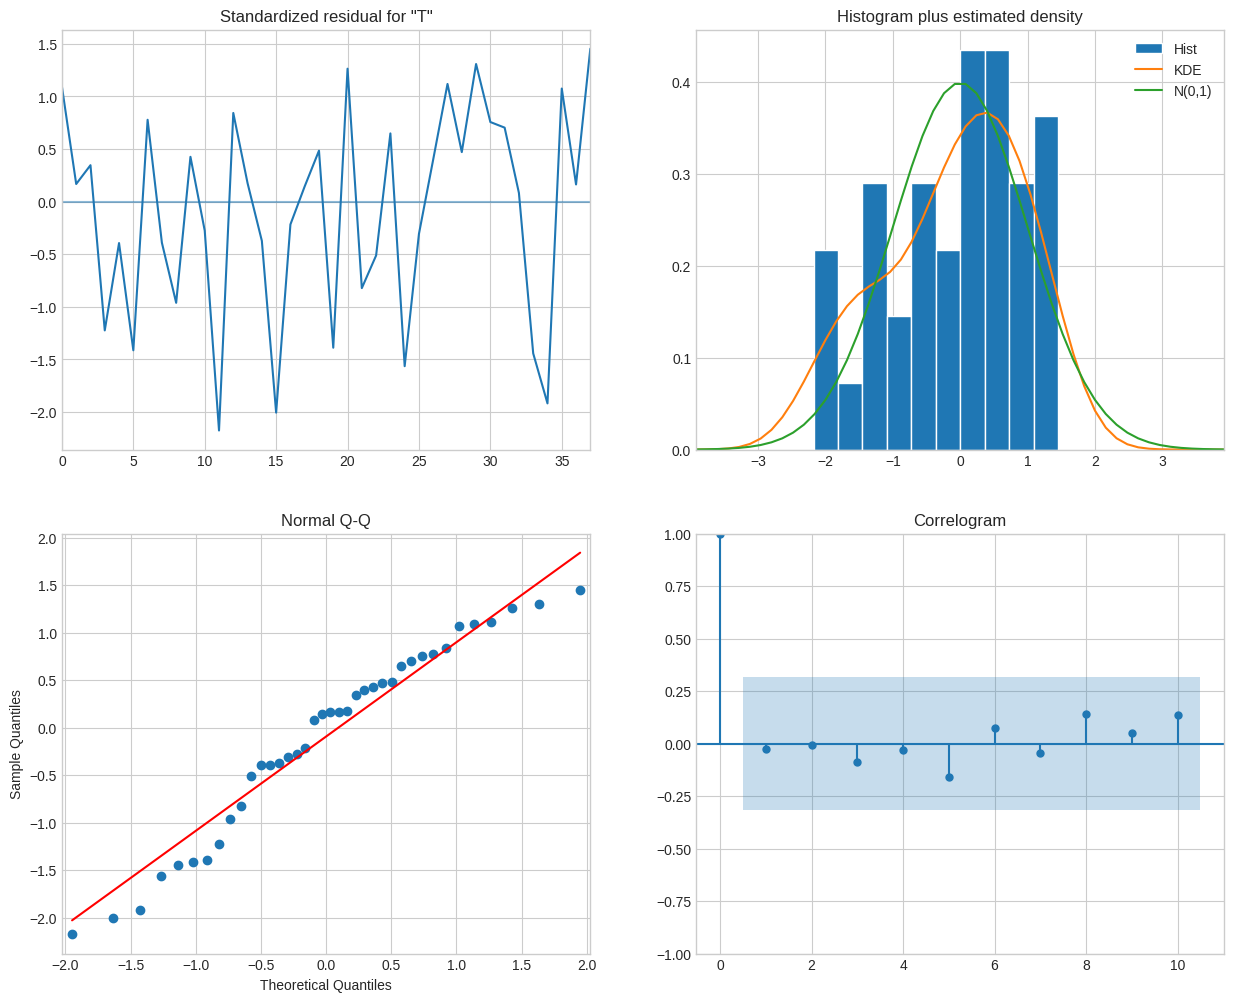

In [ ]:
# plot diagnóstico dos resíduos
fitted.plot_diagnostics(figsize=(15, 12))
plt.show()

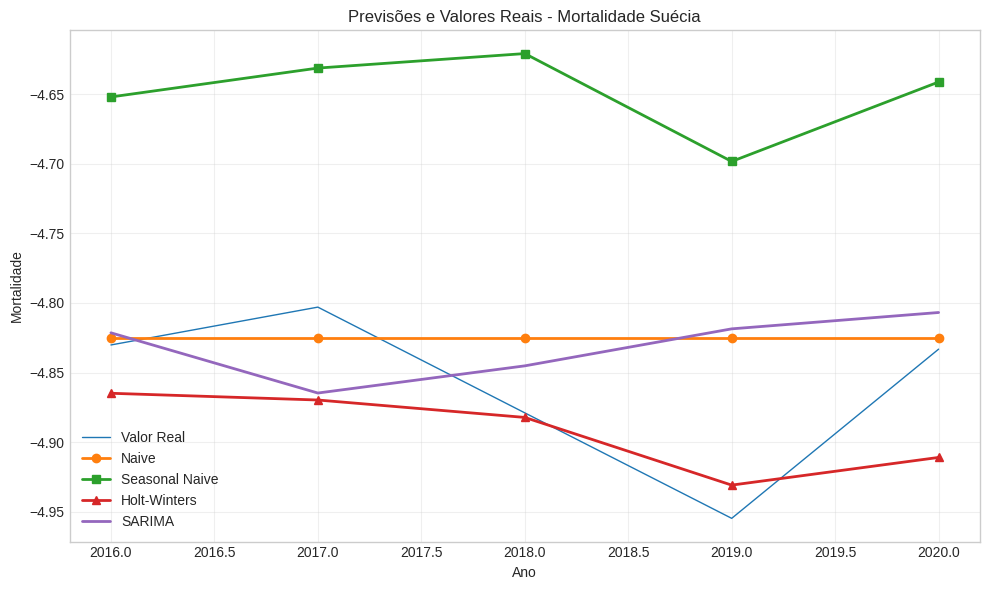

In [ ]:
# gráfico das previsões e do valor real
plt.figure(figsize=(10, 6))
plt.plot(mortality_sweden_64.index[-5:], mortality_sweden_64_log.iloc[-5:], label='Valor Real', linewidth=1)
plt.plot(mortality_sweden_64.index[-5:], results_31['Naive_Forecast'][4], 'o-', label='Naive', linewidth=2)
plt.plot(mortality_sweden_64.index[-5:], results_31['SeasonalNaive_Forecast'][4], 's-', label='Seasonal Naive', linewidth=2)
plt.plot(mortality_sweden_64.index[-5:], results_31['HoltWinters_Forecast'][4], '^-', label='Holt-Winters', linewidth=2)
plt.plot(mortality_sweden_64.index[-5:], fitted.forecast(steps=5).to_numpy(), '-', label='SARIMA', linewidth=2)
plt.xlabel('Ano')
plt.ylabel('Mortalidade')
plt.title('Previsões e Valores Reais - Mortalidade Suécia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

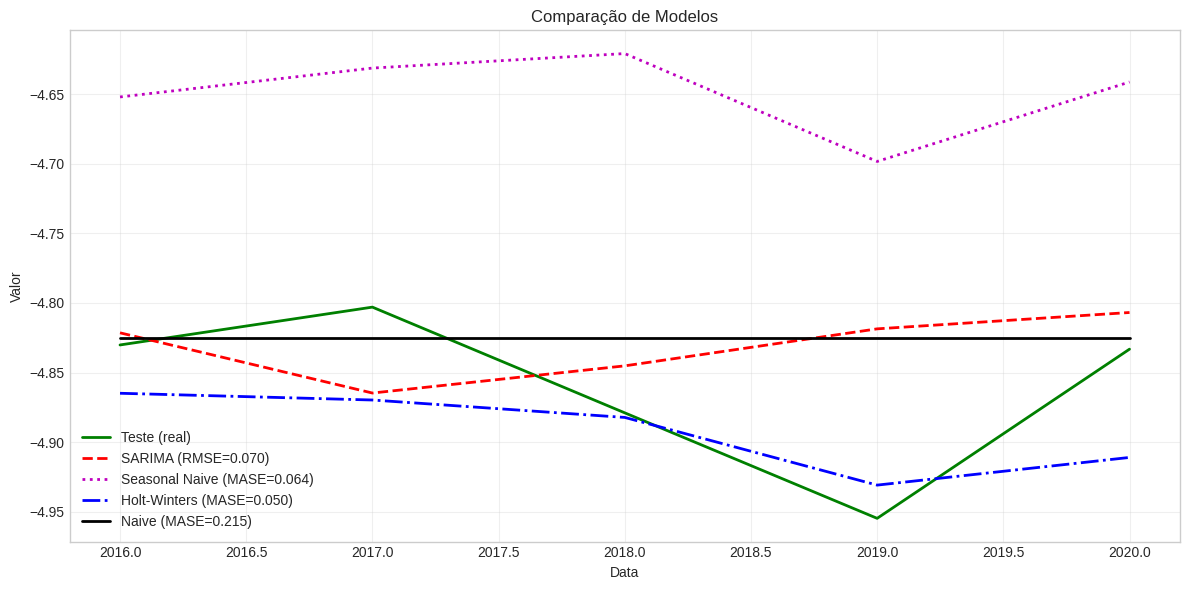

In [ ]:
# 4. Comparação SARIMA com os demais modelos

# Test
train = mortality_sweden_64_log.iloc[:-5]
test = mortality_sweden_64_log.iloc[-5:]

# Previsões
sarima_forecast = fitted.forecast(steps=5).to_numpy()
sarima_forecast = pd.Series(sarima_forecast, index=test.index)

# Naive
naive_forecast = pd.Series(results_31['Naive_Forecast'][4], index=test.index)

# Holt-winters
hw_forecast = pd.Series(results_31['HoltWinters_Forecast'][4], index=test.index)

# Seasonal Naive
sn_forecast = pd.Series(results_31['SeasonalNaive_Forecast'][4], index=test.index)

# Métricas
sarima_mae = mean_absolute_error(test, sarima_forecast)
naive_mae = mean_absolute_error(test, naive_forecast)
hw_mae = mean_absolute_error(test, hw_forecast)
sn_mae = mean_absolute_error(test, sn_forecast)

sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
sn_rmse = np.sqrt(mean_squared_error(test, naive_forecast))
hw_rmse = np.sqrt(mean_squared_error(test, hw_forecast))
naive_rmse = np.sqrt(mean_squared_error(test, sn_forecast))

# MASE
sarima_mase = mase(test, sarima_forecast, train)
sn_mase = mase(test, sn_forecast, train)
hw_mase = mase(test, hw_forecast, train)
naive_mase = mase(test, naive_forecast, train)


# Visualização
plt.figure(figsize=(12, 6))
plt.plot(test.index, test, 'g-', label='Teste (real)', linewidth=2)
plt.plot(test.index, sarima_forecast, 'r--', label=f'SARIMA (RMSE={sarima_rmse:.3f})', linewidth=2)
plt.plot(test.index, sn_forecast, 'm:', label=f'Seasonal Naive (MASE={sn_rmse:.3f})', linewidth=2)
plt.plot(test.index, hw_forecast, 'b-.', label=f'Holt-Winters (MASE={hw_rmse:.3f})', linewidth=2)
plt.plot(test.index, naive_forecast, 'k-', label=f'Naive (MASE={naive_rmse:.3f})', linewidth=2)
plt.xlabel('Data')
plt.ylabel('Valor')
plt.title('Comparação de Modelos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()



## Exercício 3.2

Baixe a série do IPCA brasileiro do SIDRA/IBGE (tabela 1737) de 2000 a 2023. Implemente uma função de validação cruzada temporal com janela expansiva para comparar três modelos: Naive, SES (Suavização Exponencial Simples) e ARIMA automático. Reporte MAE, RMSE e MASE médios sobre as dobras. Visualize as distribuições dos erros.


,value,data,variable
786,0.62,2000-01-01,Var. mensal (%)
787,0.62,2000-01-01,Var. acumulada no ano (%)
788,2.19,2000-01-01,Var. MM3M (%)
789,4.30,2000-01-01,Var. MM6M (%)
790,8.85,2000-01-01,Var. MM12M (%)


,value
data,
2000-01-01,0.62
2000-02-01,0.13
2000-03-01,0.22
2000-04-01,0.42
2000-05-01,0.01
...,...
2023-08-01,0.23
2023-09-01,0.26
2023-10-01,0.24


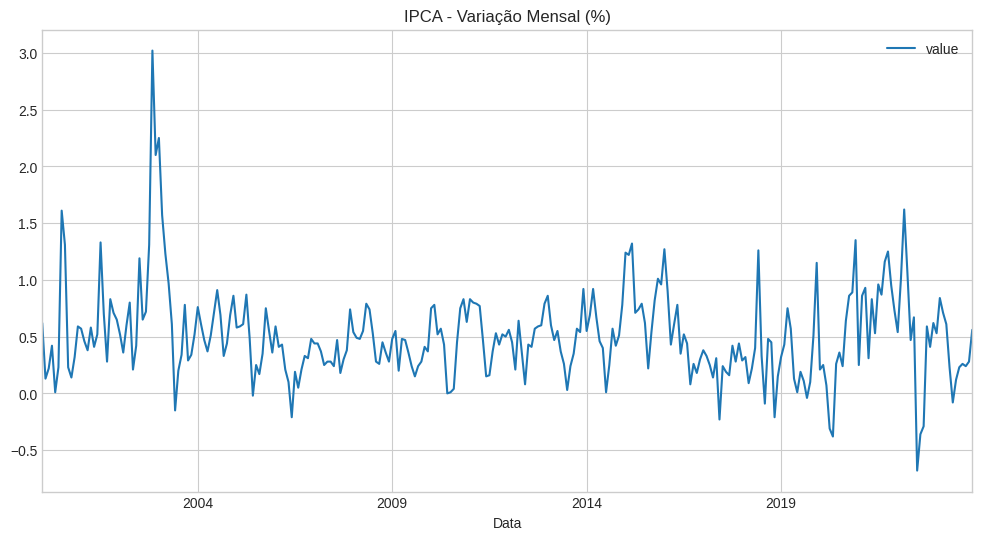

In [21]:
# Importa as variações do IPCA
ipca_raw = sidrapy.get_table(table_code = '1737',
                             territorial_level = '1',
                             ibge_territorial_code = 'all',
                             variable = '63,69,2263,2264,2265',
                             period = 'last%20472')

# Trabalhar na tabela e extrair a informação da variação mensal do IPCA da tabela
ipca =  (
    ipca_raw
    .loc[1:,['V', 'D2C', 'D3N']]
    .rename(columns = {'V': 'value',
                       'D2C': 'data',
                       'D3N': 'variable'}
            )
    .assign(variable = lambda x: x['variable'].replace({'IPCA - Variação mensal' : 'Var. mensal (%)',
                                                        'IPCA - Variação acumulada no ano': 'Var. acumulada no ano (%)',
                                                        'IPCA - Variação acumulada em 3 meses' : 'Var. MM3M (%)',
                                                        'IPCA - Variação acumulada em 6 meses': 'Var. MM6M (%)',
                                                        'IPCA - Variação acumulada em 12 meses' : 'Var. MM12M (%)'}),
            data  = lambda x: pd.to_datetime(x['data'],
                                              format = "%Y%m"),
            value = lambda x: x['value'].astype(float)
           )
    .pipe(lambda x: x.loc[(x.data >= '2000-01-01') & (x.data <= '2023-12-31')]
          )
        )

display(ipca.head())

# IPCA mensal
ipca_mensal = ipca.loc[ipca.variable == 'Var. mensal (%)'].drop(columns='variable')
ipca_mensal.set_index('data', inplace = True)

display(ipca_mensal)

# gráfico
fig, ax = plt.subplots(figsize=(12, 6))
ipca_mensal.plot(ax=ax)
plt.title('IPCA - Variação Mensal (%)')
plt.xlabel('Data')
plt.show()

In [22]:
# Validação Cruzada Temporal com Janela Expansiva

def expanding_window_cv(series, min_train_size=60, step=12, horizon=6, models=None):
    """
    Validação cruzada temporal com janela expansiva.

    Parameters:
    -----------
    series : pd.Series
        Série temporal
    min_train_size : int
        Tamanho mínimo do conjunto de treino
    step : int
        Passo entre dobras (em períodos)
    horizon : int
        Horizonte de previsão
    models : dict
        Dicionário de modelos a avaliar
    """
    n = len(series)
    results = []
    fold = 0

    for train_end in range(min_train_size, n - horizon, step):
        train = series.iloc[:train_end]
        test = series.iloc[train_end:train_end + horizon]

        fold += 1

        for model_name, model_func in models.items():
            try:
                forecast = model_func(train, horizon)
                mae = mean_absolute_error(test, forecast)
                rmse = np.sqrt(mean_squared_error(test, forecast))

                results.append({
                    'fold': fold,
                    'train_end': train.index[-1],
                    'model': model_name,
                    'MAE': mae,
                    'RMSE': rmse
                })
            except Exception as e:
                print(f"Erro no fold {fold}, modelo {model_name}: {e}")

    return pd.DataFrame(results)

# Definição dos modelos
def naive_model(train, horizon):
    """Modelo Naive - último valor observado."""
    return np.repeat(train.iloc[-1], horizon)

def ses_model(train, horizon, alpha=0.3):
    """Suavização Exponencial Simples."""
    # Implementação manual para controle
    s = np.zeros(len(train))
    s[0] = train.iloc[0]
    for t in range(1, len(train)):
        s[t] = alpha * train.iloc[t] + (1 - alpha) * s[t-1]
    return np.repeat(s[-1], horizon)

def arima_model(train, horizon):
    """ARIMA automático (simplificado - ARIMA(1,1,1))."""
    try:
        model = ARIMA(train, order=(1, 1, 1))
        fitted = model.fit()
        forecast = fitted.forecast(steps=horizon)
        return forecast
    except:
        # Fallback para naive
        return naive_model(train, horizon)

models = {
    'Naive': naive_model,
    'SES': ses_model,
    'ARIMA(1,1,1)': arima_model
}

# Executar validação cruzada
print("Executando Validação Cruzada Temporal...")
print("(Isso pode levar alguns segundos)\n")

cv_results = expanding_window_cv(
    ipca_mensal,
    min_train_size=60,   # Mínimo 5 anos de treino
    step=12,             # Passo de 1 ano
    horizon=6,           # Prever 6 meses à frente
    models=models
)

print(f"Total de dobras: {cv_results['fold'].nunique()}")
print(f"Período coberto: {cv_results['train_end'].min()} a {cv_results['train_end'].max()}")

Executando Validação Cruzada Temporal...
(Isso pode levar alguns segundos)

Total de dobras: 19
Período coberto: 2004-12-01 00:00:00 a 2022-12-01 00:00:00


RESULTADOS DA VALIDAÇÃO CRUZADA TEMPORAL

Média ± Desvio Padrão por Modelo:

ARIMA(1,1,1):
  MAE:  0.2639 ± 0.1284
  RMSE: 0.3169 ± 0.1439

Naive:
  MAE:  0.3180 ± 0.2358
  RMSE: 0.3726 ± 0.2349

SES:
  MAE:  0.2394 ± 0.1079
  RMSE: 0.2950 ± 0.1221

ARIMA(1,1,1) MASE: 0.8298
Naive MASE: 1.0000
SES MASE: 0.7528


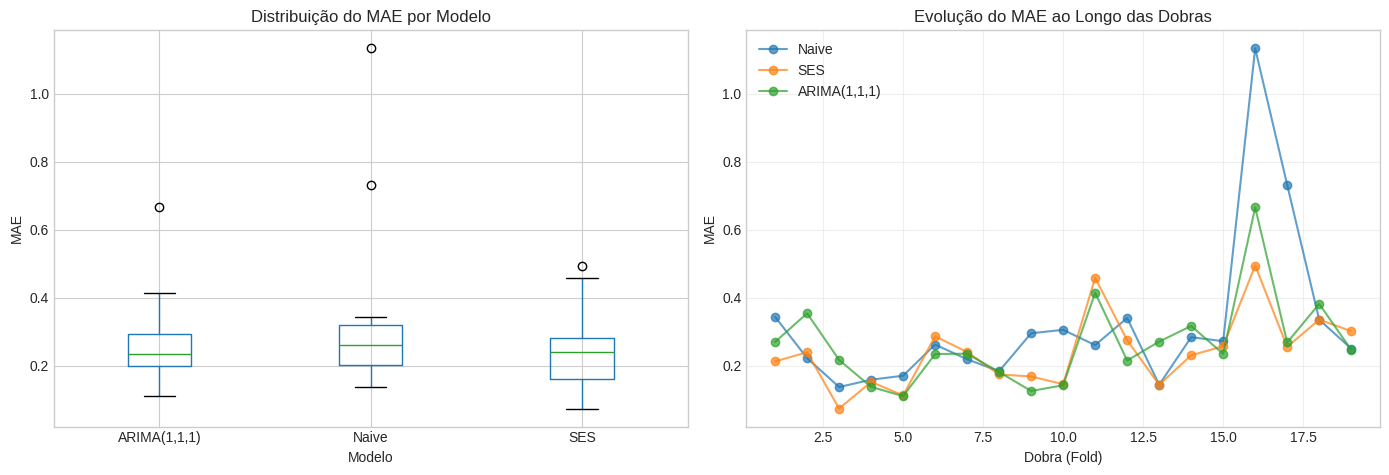

In [23]:
# Análise dos resultados da validação cruzada

# Resumo por modelo
summary = cv_results.groupby('model')[['MAE', 'RMSE']].agg(['mean', 'std'])

print("RESULTADOS DA VALIDAÇÃO CRUZADA TEMPORAL")
print("="*60)
print("\nMédia ± Desvio Padrão por Modelo:\n")

for model in summary.index:
    mae_mean = summary.loc[model, ('MAE', 'mean')]
    mae_std = summary.loc[model, ('MAE', 'std')]
    rmse_mean = summary.loc[model, ('RMSE', 'mean')]
    rmse_std = summary.loc[model, ('RMSE', 'std')]
    print(f"{model}:")
    print(f"  MAE:  {mae_mean:.4f} ± {mae_std:.4f}")
    print(f"  RMSE: {rmse_mean:.4f} ± {rmse_std:.4f}")
    print()

# Calcular MASE (erro relativo ao Naive)
naive_mae = summary.loc['Naive', ('MAE', 'mean')]
for model in summary.index:
    mase = summary.loc[model, ('MAE', 'mean')] / naive_mae
    print(f"{model} MASE: {mase:.4f}")

# Visualização das distribuições de erro
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot do MAE
cv_results.boxplot(column='MAE', by='model', ax=axes[0])
axes[0].set_title('Distribuição do MAE por Modelo')
axes[0].set_xlabel('Modelo')
axes[0].set_ylabel('MAE')

# Evolução do erro ao longo do tempo
for model in cv_results['model'].unique():
    model_data = cv_results[cv_results['model'] == model]
    axes[1].plot(model_data['fold'], model_data['MAE'], 'o-', label=model, alpha=0.7)

axes[1].set_xlabel('Dobra (Fold)')
axes[1].set_ylabel('MAE')
axes[1].set_title('Evolução do MAE ao Longo das Dobras')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('')  # Remove título automático do boxplot
plt.tight_layout()
plt.show()

### Discussão Exercício 3.3

**Resultados da validação cruzada temporal:**
- A validação cruzada temporal é essencial para séries temporais, pois preserva a ordem cronológica
- Janela expansiva permite usar dados acumulados, melhorando a estimação ao longo do tempo
- O SES é uma alternativa robusta quando a série não tem padrões complexos

---

## Exercício 3.4: Comparação MASE vs MAPE

**Enunciado:** Explique por que o MASE é preferível ao MAPE para avaliar previsões de séries temporais econômicas. Dê um exemplo numérico onde o MAPE falha mas o MASE permanece bem comportado. Implemente ambas as métricas em Python.

### Exercício 3.3

Ajuste um modelo Holt-Winters aos dados de taxa de câmbio BRL/USD (dados do BCB, série 1) para o período 2019-2023. Experimente ambas as variantes: sazonalidade aditiva e multiplicativa. Use validação cruzada com janela deslizante de 60 dias para determinar qual variante produz menores erros de previsão em horizontes de 1, 5 e 10 dias.


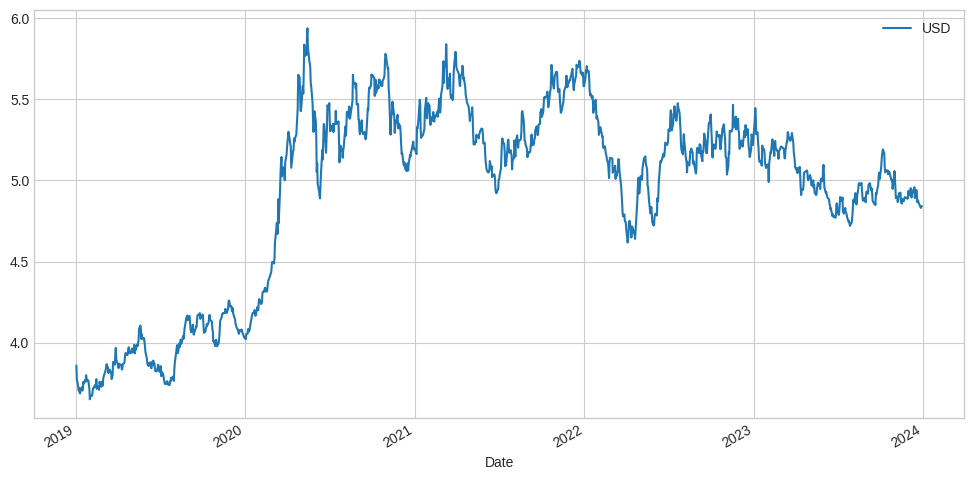

In [29]:
# Buscar preços de compra/venda do USD
usd = currency.get("USD", start="2019-01-01", end="2023-12-31")

usd.plot();

Iniciando validação cruzada para Holt-Winters (Aditivo e Multiplicativo) nos dados BRL/USD...

Validação cruzada concluída. Analisando resultados...

Resumo dos resultados da Validação Cruzada Holt-Winters (MAE e RMSE médios):
                                  MAE                          RMSE            \
horizon                            1         5         10        1         5    
model_type                                                                      
Holt-Winters Aditivo         0.032036  0.083575  0.123814  0.032036  0.098092   
Holt-Winters Multiplicativo  0.032008  0.083781  0.124010  0.032008  0.098327   

                                       
horizon                            10  
model_type                             
Holt-Winters Aditivo         0.140789  
Holt-Winters Multiplicativo  0.140984  

Modelo Holt-Winters preferido (menor MAE médio) por horizonte:
  Horizonte 1 dias: Holt-Winters Multiplicativo
  Horizonte 5 dias: Holt-Winters Aditivo
  Horizonte 10

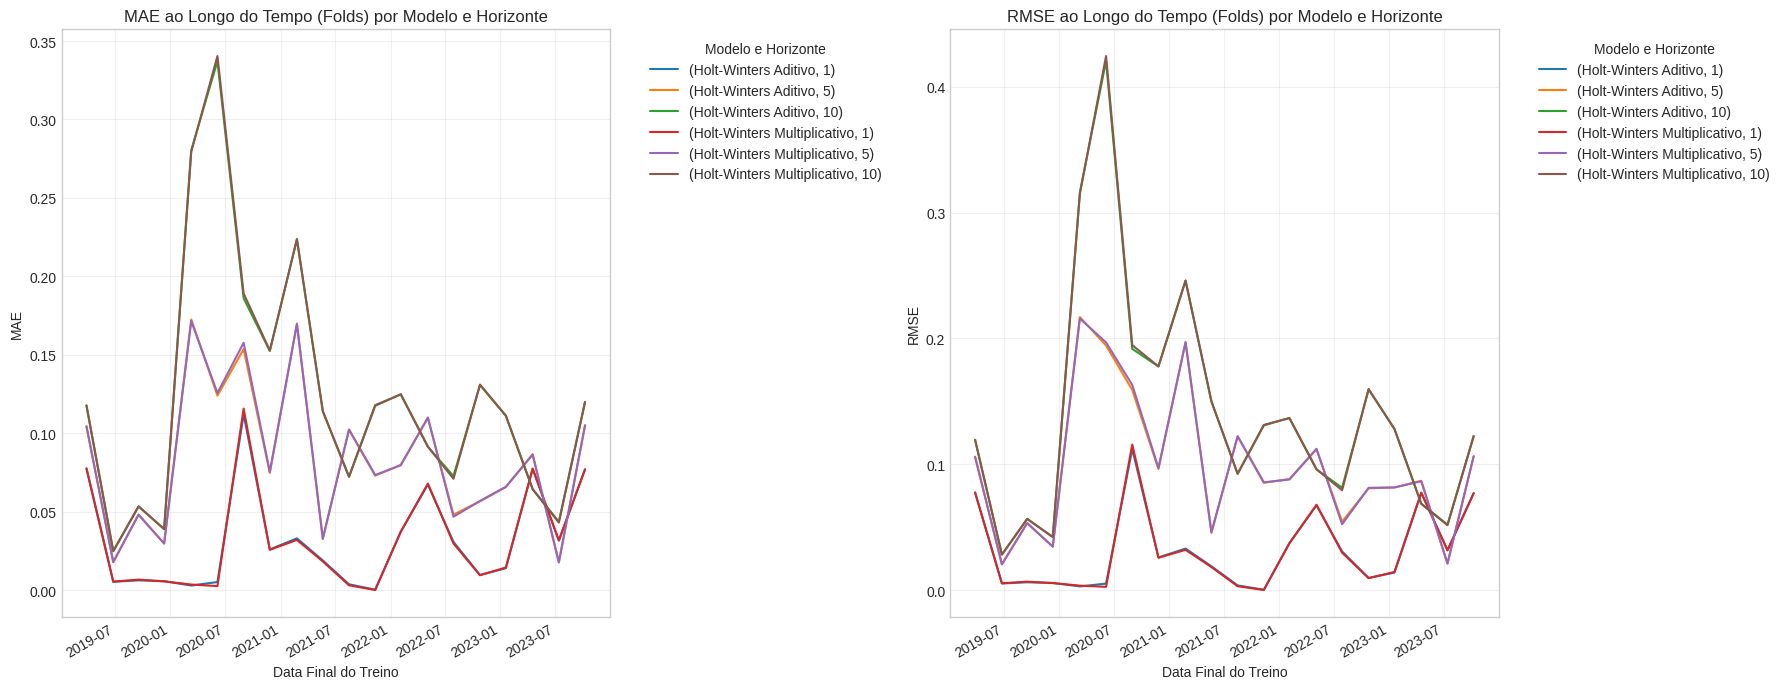


Tabela Detalhada de MAE e RMSE (Média ± Desvio Padrão):
                                          MAE                RMSE          
                                         mean       std      mean       std
model_type                  horizon                                        
Holt-Winters Aditivo        1        0.032036  0.032717  0.032036  0.032717
                            5        0.083575  0.046885  0.098092  0.056873
                            10       0.123814  0.080606  0.140789  0.096262
Holt-Winters Multiplicativo 1        0.032008  0.033326  0.032008  0.033326
                            5        0.083781  0.047207  0.098327  0.057283
                            10       0.124010  0.081145  0.140984  0.096923


In [30]:
import pandas as pd
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore') # Ignorar warnings de convergência do statsmodels

# 1. Preparar os dados
exchange_rate = usd['USD']

# 2. Definir uma função para validação cruzada com janela expansiva para Holt-Winters
def holt_winters_cv(series, min_train_size, step, horizons, seasonal_period=7):
    results = []
    n = len(series)

    # Garante que o tamanho mínimo de treino seja suficiente para o modelo sazonal
    min_train_size_adjusted = max(min_train_size, 2 * seasonal_period + 1)

    # Itera pela série, criando janelas de treino expansivas
    # train_end_idx é o índice *exclusivo* do final do conjunto de treino
    for train_end_idx in range(min_train_size_adjusted, n - max(horizons) + 1, step):
        train = series.iloc[:train_end_idx]

        for h in horizons:
            if train_end_idx + h > n: # Garante que o conjunto de teste não exceda os dados disponíveis
                continue

            test = series.iloc[train_end_idx : train_end_idx + h]

            # Holt-Winters Aditivo
            try:
                hw_add = ExponentialSmoothing(
                    train,
                    seasonal_periods=seasonal_period,
                    trend='add',
                    seasonal='add',
                    initialization_method="estimated"
                ).fit()
                forecast_add = hw_add.forecast(h)
                mae_add = mean_absolute_error(test, forecast_add)
                rmse_add = np.sqrt(mean_squared_error(test, forecast_add))

                results.append({
                    'train_end_date': train.index[-1],
                    'model_type': 'Holt-Winters Aditivo',
                    'horizon': h,
                    'MAE': mae_add,
                    'RMSE': rmse_add
                })
            except Exception as e:
                results.append({
                    'train_end_date': train.index[-1],
                    'model_type': 'Holt-Winters Aditivo',
                    'horizon': h,
                    'MAE': np.nan,
                    'RMSE': np.nan
                })

            # Holt-Winters Multiplicativo
            try:
                hw_mul = ExponentialSmoothing(
                    train,
                    seasonal_periods=seasonal_period,
                    trend='add', # O trend geralmente permanece aditivo, a sazonalidade muda
                    seasonal='mul',
                    initialization_method="estimated"
                ).fit()
                forecast_mul = hw_mul.forecast(h)
                mae_mul = mean_absolute_error(test, forecast_mul)
                rmse_mul = np.sqrt(mean_squared_error(test, forecast_mul))

                results.append({
                    'train_end_date': train.index[-1],
                    'model_type': 'Holt-Winters Multiplicativo',
                    'horizon': h,
                    'MAE': mae_mul,
                    'RMSE': rmse_mul
                })
            except Exception as e:
                results.append({
                    'train_end_date': train.index[-1],
                    'model_type': 'Holt-Winters Multiplicativo',
                    'horizon': h,
                    'MAE': np.nan,
                    'RMSE': np.nan
                })

    return pd.DataFrame(results)

# Parâmetros para a validação cruzada
# 'janela deslizante de 60 dias' será interpretado como um 'step' de 60 dias para a janela de treino expansiva.
min_train_initial = 60 # Tamanho mínimo inicial da janela de treino (dias)
step_size = 60       # Incremento da janela de treino a cada dobra (dias)
forecast_horizons = [1, 5, 10] # Horizontes de previsão em dias
seasonal_period = 7  # Assumindo sazonalidade semanal para dados diários de câmbio

print("Iniciando validação cruzada para Holt-Winters (Aditivo e Multiplicativo) nos dados BRL/USD...")

cv_results_hw = holt_winters_cv(
    series=exchange_rate,
    min_train_size=min_train_initial,
    step=step_size,
    horizons=forecast_horizons,
    seasonal_period=seasonal_period
)

print("\nValidação cruzada concluída. Analisando resultados...")

# 3. Análise dos resultados
# Agrupa por tipo de modelo e horizonte para obter MAE e RMSE médios
summary_hw = cv_results_hw.groupby(['model_type', 'horizon'])[['MAE', 'RMSE']].mean().unstack()

print("\nResumo dos resultados da Validação Cruzada Holt-Winters (MAE e RMSE médios):")
print("="*70)
print(summary_hw)
print("="*70)

# Determina o melhor modelo para cada horizonte com base no MAE
best_models_mae = {}
for h in forecast_horizons:
    # Certifica-se de que a coluna existe antes de tentar acessá-la
    col_mae = ('MAE', h)
    if col_mae in summary_hw.columns:
        best_model_for_h = summary_hw[col_mae].idxmin()
        best_models_mae[h] = best_model_for_h
    else:
        # Fallback para caso o unstack não funcione como esperado ou para depuração
        temp_summary = cv_results_hw[cv_results_hw['horizon'] == h].groupby('model_type')['MAE'].mean()
        if not temp_summary.empty:
            best_model_for_h = temp_summary.idxmin()
            best_models_mae[h] = best_model_for_h

print("\nModelo Holt-Winters preferido (menor MAE médio) por horizonte:")
for h, model_name in best_models_mae.items():
    print(f"  Horizonte {h} dias: {model_name}")

# 4. Visualização dos resultados
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot MAE ao longo do tempo para cada modelo e horizonte
cv_results_hw.pivot_table(index='train_end_date', columns=['model_type', 'horizon'], values='MAE').plot(ax=axes[0])
axes[0].set_title('MAE ao Longo do Tempo (Folds) por Modelo e Horizonte')
axes[0].set_xlabel('Data Final do Treino')
axes[0].set_ylabel('MAE')
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='Modelo e Horizonte', bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot RMSE ao longo do tempo para cada modelo e horizonte
cv_results_hw.pivot_table(index='train_end_date', columns=['model_type', 'horizon'], values='RMSE').plot(ax=axes[1])
axes[1].set_title('RMSE ao Longo do Tempo (Folds) por Modelo e Horizonte')
axes[1].set_xlabel('Data Final do Treino')
axes[1].set_ylabel('RMSE')
axes[1].grid(True, alpha=0.3)
axes[1].legend(title='Modelo e Horizonte', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Tabela detalhada de MAE e RMSE médios e desvios padrão
print("\nTabela Detalhada de MAE e RMSE (Média ± Desvio Padrão):")
detailed_summary = cv_results_hw.groupby(['model_type', 'horizon'])[['MAE', 'RMSE']].agg(['mean', 'std'])
print(detailed_summary)

### Discussão Exercício 3.3: Análise dos Modelos Holt-Winters

A validação cruzada temporal foi realizada para comparar as variantes Aditiva e Multiplicativa do modelo Holt-Winters na previsão da taxa de câmbio BRL/USD, em horizontes de 1, 5 e 10 dias. Os resultados médios de MAE (Mean Absolute Error) e RMSE (Root Mean Squared Error) fornecem insights sobre o desempenho de cada modelo.

**Principais Observações:**

*   **Horizonte de 1 Dia:** O modelo **Holt-Winters Multiplicativo** apresentou um MAE ligeiramente menor (0.032008) em comparação com o Aditivo (0.032036). Isso sugere que, para previsões de curtíssimo prazo, as flutuações sazonais podem ser melhor capturadas como uma proporção do nível da série.

*   **Horizonte de 5 e 10 Dias:** Para horizontes de previsão mais longos (5 e 10 dias), o modelo **Holt-Winters Aditivo** demonstrou um desempenho superior, com menores valores de MAE (0.083575 vs 0.083781 para 5 dias; 0.123814 vs 0.124010 para 10 dias) e RMSE. Isso pode indicar que, a médio prazo, a sazonalidade nos dados de câmbio se manifesta de forma mais constante, independentemente do nível geral da série, favorecendo o componente sazonal aditivo.

**Conclusão:**

Não há um modelo universalmente superior para todos os horizontes. O Holt-Winters Multiplicativo parece ser marginalmente melhor para previsões de curtíssimo prazo (1 dia), enquanto o Holt-Winters Aditivo mostra-se mais eficaz para previsões de médio prazo (5 e 10 dias) neste conjunto de dados. A escolha do modelo ideal dependerá do horizonte de previsão específico que se deseja otimizar. As visualizações dos erros ao longo do tempo (folds) também são cruciais para entender a estabilidade e a consistência do desempenho de cada modelo.